# ForecastLab — EXP-005 Time Series Diagnostics

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-002 |
| **Eksperimen** | EXP-005 |
| **Dataset** | featured_data.csv |
| **Author** | GAKUSEI Najib |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
print(f'Loaded: {df.shape}')

Loaded: (52272, 47)


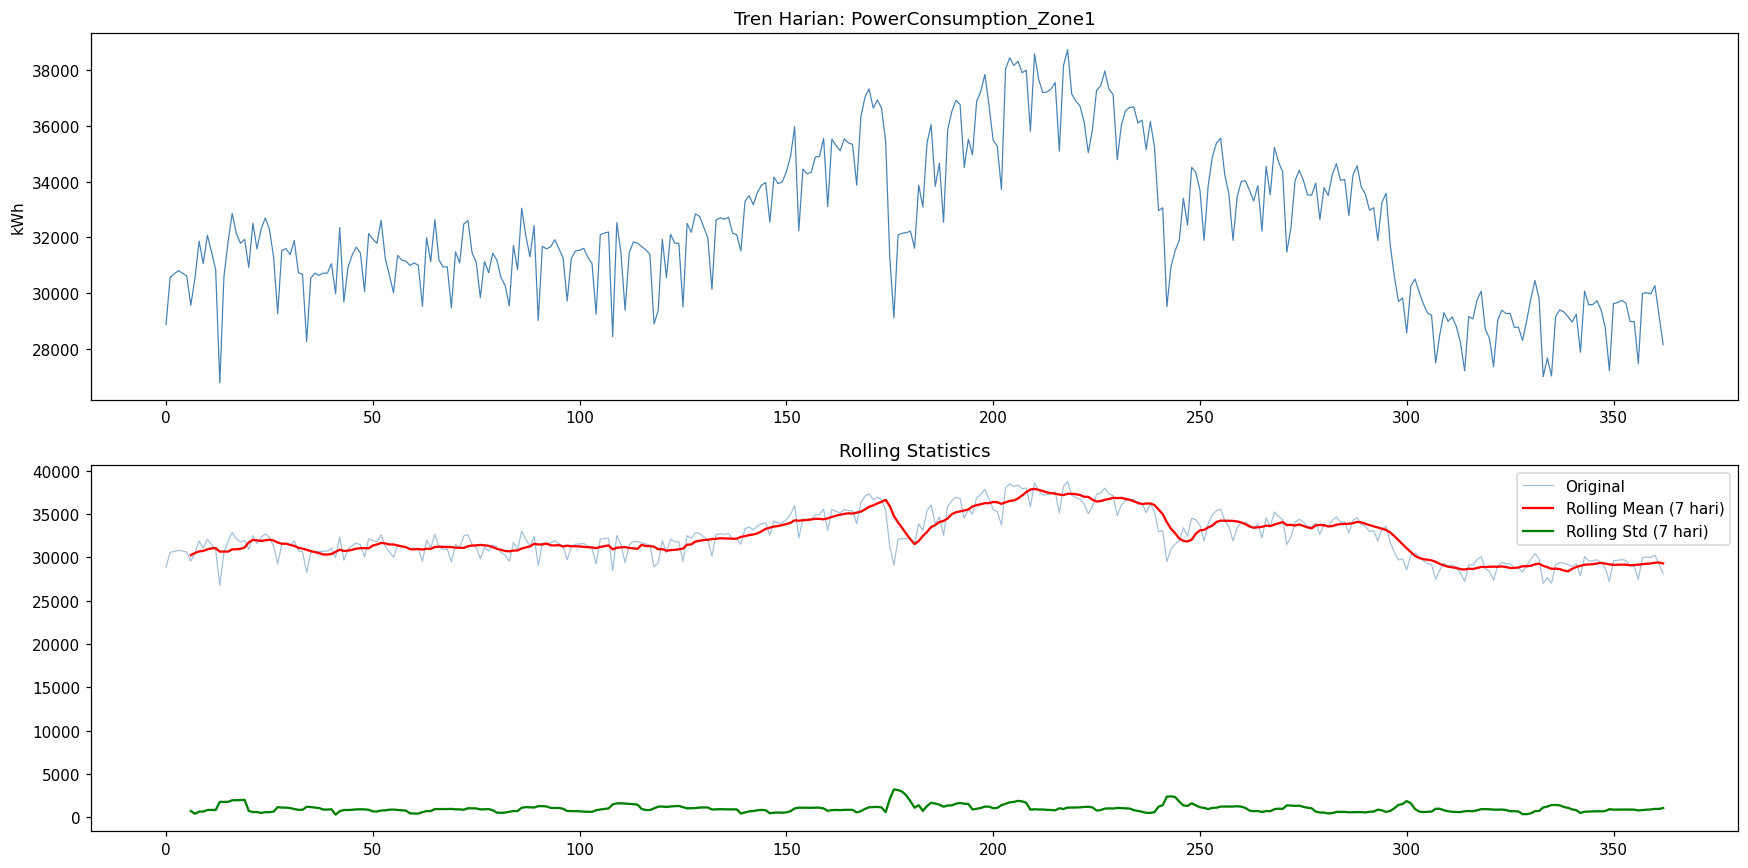

In [2]:
target = 'PowerConsumption_Zone1'
daily = df.groupby(df['Datetime'].dt.date)[target].mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(daily.values, color='steelblue', linewidth=0.8)
axes[0].set_title(f'Tren Harian: {target}')
axes[0].set_ylabel('kWh')

rolling_mean = daily.rolling(7).mean()
rolling_std = daily.rolling(7).std()
axes[1].plot(daily.values, color='steelblue', linewidth=0.8, alpha=0.5, label='Original')
axes[1].plot(rolling_mean.values, color='red', linewidth=1.5, label='Rolling Mean (7 hari)')
axes[1].plot(rolling_std.values, color='green', linewidth=1.5, label='Rolling Std (7 hari)')
axes[1].set_title('Rolling Statistics')
axes[1].legend()
plt.tight_layout()
plt.savefig('../data/diagnostics_01_tren.png', bbox_inches='tight', dpi=110)
plt.show()

In [3]:
result = adfuller(daily.values)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Stationary' if result[1] < 0.05 else 'Non-Stationary')

ADF Statistic: -1.4272
p-value: 0.5692
Non-Stationary


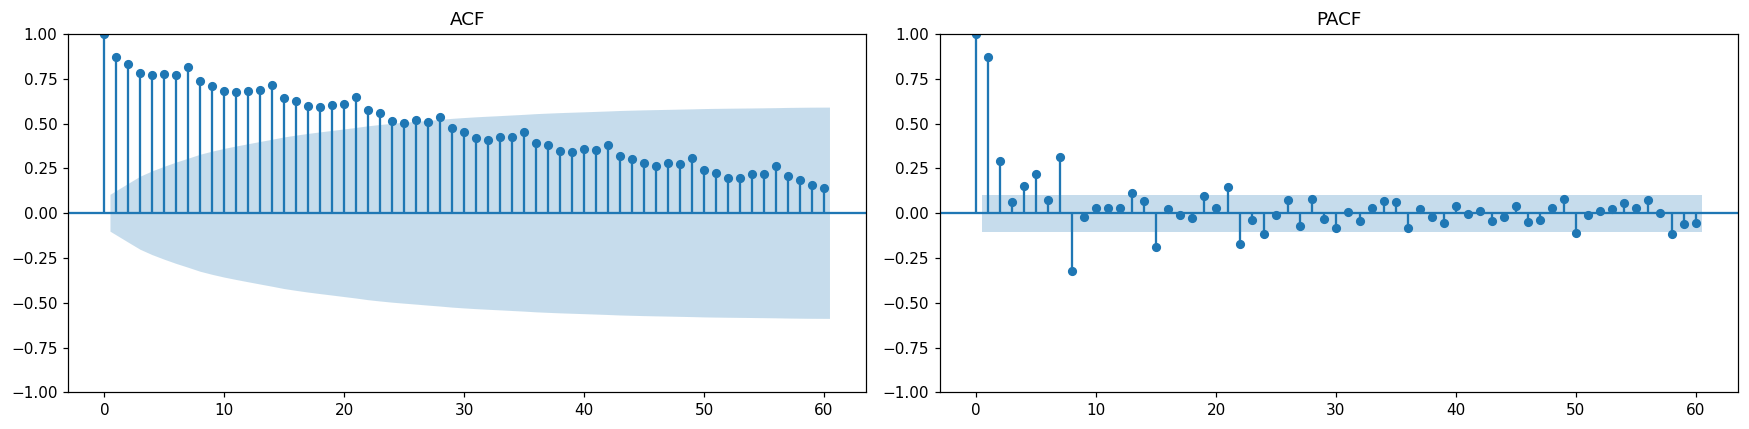

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(daily.values, lags=60, ax=axes[0])
axes[0].set_title('ACF')
plot_pacf(daily.values, lags=60, ax=axes[1])
axes[1].set_title('PACF')
plt.tight_layout()
plt.savefig('../data/diagnostics_02_acf_pacf.png', bbox_inches='tight', dpi=110)
plt.show()

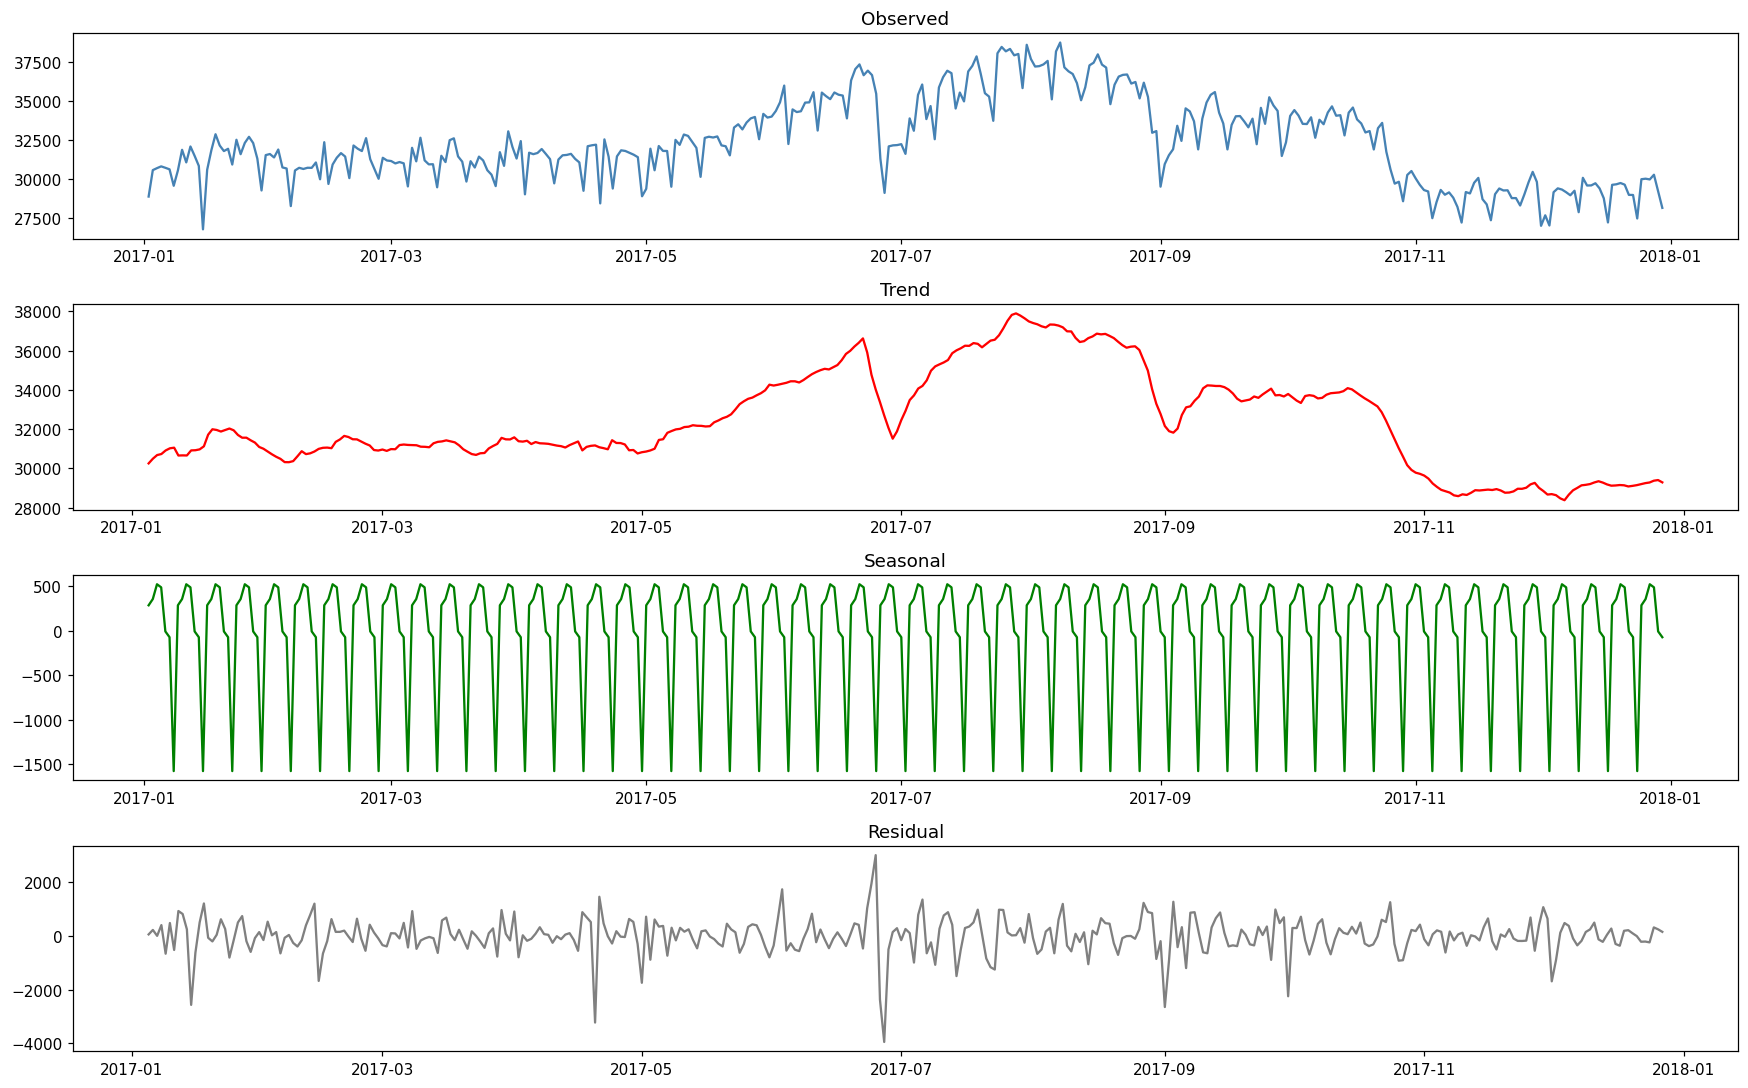

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(daily, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(16, 10))
axes[0].plot(decomp.observed, color='steelblue'); axes[0].set_title('Observed')
axes[1].plot(decomp.trend, color='red'); axes[1].set_title('Trend')
axes[2].plot(decomp.seasonal, color='green'); axes[2].set_title('Seasonal')
axes[3].plot(decomp.resid, color='gray'); axes[3].set_title('Residual')
plt.tight_layout()
plt.savefig('../data/diagnostics_03_decomposition.png', bbox_inches='tight', dpi=110)
plt.show()

---
## Kesimpulan

- Data menunjukkan pola musiman harian yang kuat
- ACF/PACF menunjukkan autokorelasi signifikan
- Decomposition: trend naik di pertengahan tahun, seasonal mingguan

**Next: EXP-006 Baseline**